# 02 — Feature engineering and target formulation

**What this notebook establishes:** the feature set, the leakage discipline
that makes the validation honest, and the single design decision the framework
turns on — regressing on the **change** rather than the level.

The code here imports the *actual* implementation from `backend/forecasting/`,
not a reimplementation, so what is demonstrated is what the experiments ran.

In [1]:
import marisviz as mv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mv.setup()

from forecasting.config import get_config
from forecasting.feature_engineering import TARGET, TARGET_ANCHOR, build_features
from forecasting.registry import resolve

config = get_config()
series = mv.load_series()
print("imported the shipped implementation from backend/forecasting/")

imported the shipped implementation from backend/forecasting/


## Building one site's feature matrix

A single (variable, site) pair, run through the real feature builder. Every
variable goes through this identical path.

In [2]:
VARIABLE, SITE, HORIZON = "water_temperature", "gulf_stream", 7

one = series[(series["variable"] == VARIABLE) & (series["site"] == SITE)]
wide = one.pivot_table(index="timestamp", columns="field", values="value",
                       observed=True).reset_index()
latitude = float(one["latitude"].iloc[0]); longitude = float(one["longitude"].iloc[0])

variable = resolve(VARIABLE, config)
matrix = build_features(
    wide, variable, config.features_for(VARIABLE),
    latitude=latitude, longitude=longitude, horizon=HORIZON,
)
print(f"{len(matrix.frame):,} rows x {len(matrix.feature_columns)} features")
print(f"categorical: {matrix.categorical_columns}")

791 rows x 59 features
categorical: ['basin']


### The last *h* rows have no target, and must be dropped

The target is built by shifting the observed series **backwards** by the
horizon, so the final `HORIZON` rows have nothing to predict. The trainer drops
them (`frame.dropna(subset=[TARGET])`) and so must anything that reproduces it —
leaving them in silently poisons every statistic downstream with NaN.

This is the one place the notebook has to mirror the trainer rather than just
call it, so it is done explicitly and checked.

In [3]:
frame = matrix.frame.dropna(subset=[TARGET, TARGET_ANCHOR]).reset_index(drop=True)
print(f"built {len(matrix.frame):,} rows -> {len(frame):,} usable "
      f"({len(matrix.frame) - len(frame)} dropped, horizon = {HORIZON})")
assert frame[TARGET].notna().all() and frame[TARGET_ANCHOR].notna().all()

built 791 rows -> 784 usable (7 dropped, horizon = 7)


In [4]:
# The feature families, by name pattern -- this is the whole predictor set.
import re
families = {
    "lag":        r"_lag\d+$",
    "rolling":    r"_roll\d+_(mean|std|min|max)$",
    "difference": r"_diff\d*$",
    "trend":      r"_trend\d+$",
    "calendar":   r"^(day_of_year|month|week|year)|(_sin|_cos)$",
    "static":     r"^(latitude|longitude|ocean_depth|basin)$",
}
rows = []
for name, pattern in families.items():
    hits = [c for c in matrix.feature_columns if re.search(pattern, c)]
    rows.append({"family": name, "count": len(hits), "example": hits[0] if hits else "-"})
pd.DataFrame(rows)

,family,count,example
0,lag,10,water_temperature_lag1
1,rolling,24,water_temperature_roll7_mean
2,difference,2,water_temperature_diff1
3,trend,4,water_temperature_trend7
4,calendar,7,month
5,static,4,ocean_depth


## What the derived features look like

Lags and rolling windows all close at time *t* inclusive — they look backwards
only. That is safe precisely because the horizon is at least 1 day, so the
target lives strictly beyond the newest information used to predict it.

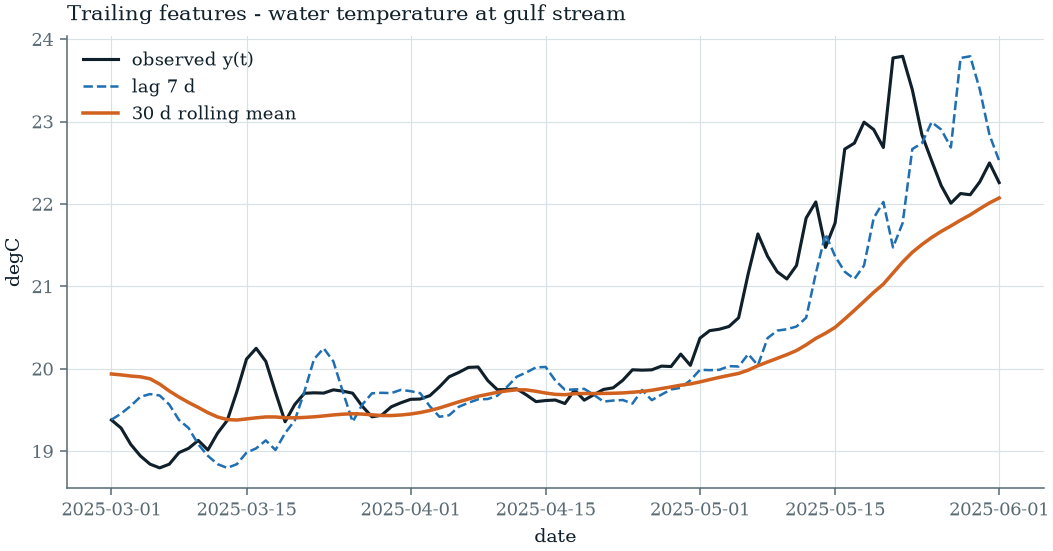

In [5]:
f = frame.set_index("timestamp")
window = f.loc["2025-03-01":"2025-06-01"]
col = variable.code

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(window.index, window[col], color=mv.INK, linewidth=1.6, label="observed y(t)")
if f"{col}_lag7" in window:
    ax.plot(window.index, window[f"{col}_lag7"], color=mv.PERSISTENCE,
            linewidth=1.3, linestyle="--", label="lag 7 d")
if f"{col}_roll30_mean" in window:
    ax.plot(window.index, window[f"{col}_roll30_mean"], color=mv.CLIMATOLOGY,
            linewidth=1.8, label="30 d rolling mean")
ax.set(xlabel="date", ylabel="degC",
       title=f"Trailing features - {mv.pretty(VARIABLE)} at {mv.pretty(SITE)}")
ax.legend()
mv.save(fig, "02_features")
plt.show()

## Calendar features are encoded cyclically

Day-of-year 365 and day 1 are one day apart, but as raw integers they are 364
apart. Sine/cosine encoding restores the adjacency, which lets a tree split on
"late December *or* early January" as a single region.

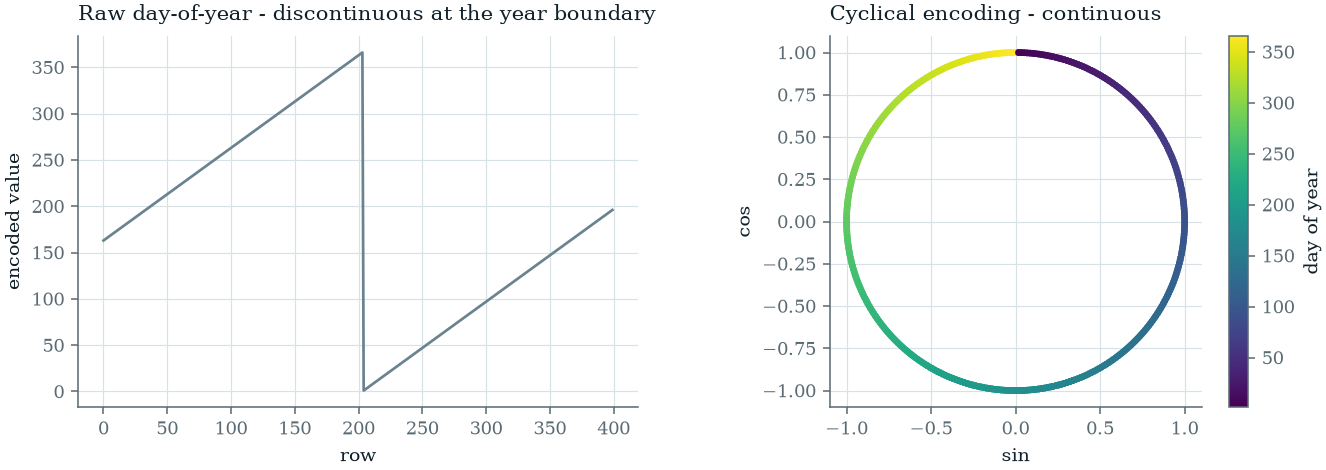

In [6]:
sin_col = next((c for c in f.columns if c.endswith("_sin")), None)
cos_col = next((c for c in f.columns if c.endswith("_cos")), None)

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.6))
axes[0].plot(np.arange(400), f["day_of_year"].to_numpy()[:400],
             color=mv.MUTED, linewidth=1.4)
axes[0].set(title="Raw day-of-year - discontinuous at the year boundary",
            xlabel="row", ylabel="encoded value")
if sin_col and cos_col:
    sc = axes[1].scatter(f[sin_col], f[cos_col], s=6, c=f.index.dayofyear,
                         cmap=mv.SEQUENTIAL)
    fig.colorbar(sc, ax=axes[1], label="day of year")
    axes[1].set(title="Cyclical encoding - continuous", xlabel="sin", ylabel="cos")
    axes[1].set_aspect("equal")
fig.tight_layout()
mv.save(fig, "02_cyclical")
plt.show()

## The target: level vs. change

This is the decision the framework turns on.

A regression tree partitions feature space into piecewise-constant regions. It
therefore **cannot represent the identity function** $y(t+h) = y(t)$ — which is
exactly what persistence is. Asked to predict the *level*, a tree must
reconstruct the entire dynamic range from splits, and on a smooth autocorrelated
series it loses to simply repeating the last value.

Asked to predict the *change*, persistence becomes the constant zero function,
which a tree represents exactly. The model then only has to find departures from
persistence — and anything it learns is pure gain.

Below, both are fitted on identical data and features.

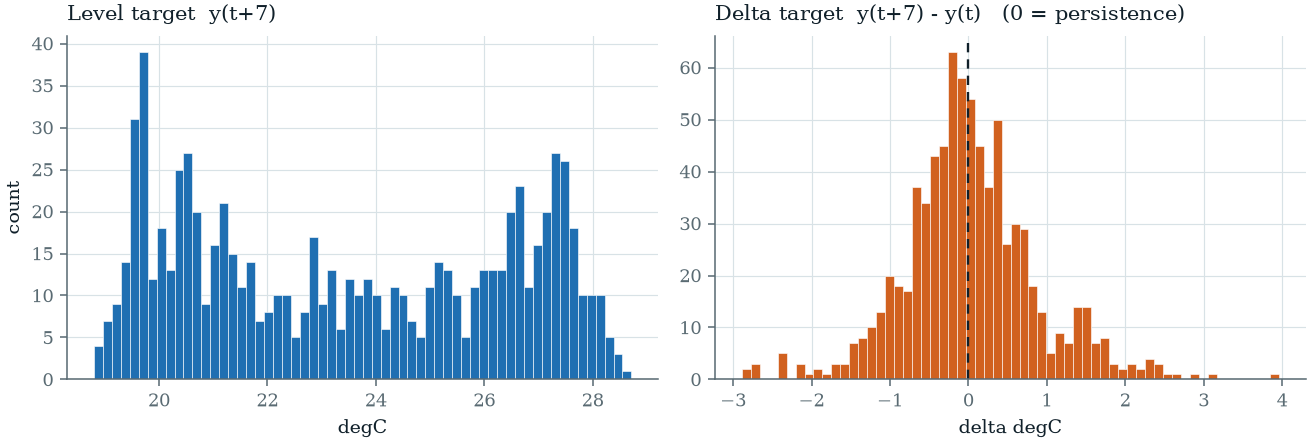

level : mean  23.472  sd  2.947
delta : mean   0.020  sd  0.863


In [7]:
target_level = frame[TARGET].to_numpy(dtype="float64")
anchor       = frame[TARGET_ANCHOR].to_numpy(dtype="float64")
delta        = target_level - anchor

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))
axes[0].hist(target_level, bins=60, color=mv.PERSISTENCE, edgecolor="white", linewidth=0.3)
axes[0].set(title=f"Level target  y(t+{HORIZON})", xlabel="degC", ylabel="count")
axes[1].hist(delta, bins=60, color=mv.CLIMATOLOGY, edgecolor="white", linewidth=0.3)
axes[1].axvline(0, color=mv.INK, linewidth=1.2, linestyle=(0, (4, 3)))
axes[1].set(title=f"Delta target  y(t+{HORIZON}) - y(t)   (0 = persistence)",
            xlabel="delta degC")
fig.tight_layout()
mv.save(fig, "02_targets")
plt.show()

print(f"level : mean {target_level.mean():7.3f}  sd {target_level.std():6.3f}")
print(f"delta : mean {delta.mean():7.3f}  sd {delta.std():6.3f}")

In [8]:
from lightgbm import LGBMRegressor

X = frame[matrix.feature_columns]
cats = [c for c in matrix.categorical_columns if c in X.columns]
cut = int(len(X) * 0.8)          # chronological split; never random
tr, te = slice(0, cut), slice(cut, len(X))

def fit_predict(y_train):
    m = LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31,
                      random_state=42, verbose=-1)
    m.fit(X.iloc[tr], y_train, categorical_feature=cats)
    return np.asarray(m.predict(X.iloc[te]), dtype="float64")

truth   = target_level[te]
persist = anchor[te]

def rmse(pred):
    return float(np.sqrt(np.mean((pred - truth) ** 2)))

rmse_pers  = rmse(persist)
rmse_level = rmse(fit_predict(target_level[tr]))
rmse_delta = rmse(fit_predict(delta[tr]) + persist)

print(f"test rows          {len(truth)}")
print(f"persistence RMSE   {rmse_pers:.4f}")
print(f"level target RMSE  {rmse_level:.4f}   skill {mv.skill(rmse_level, rmse_pers):+.4f}")
print(f"delta target RMSE  {rmse_delta:.4f}   skill {mv.skill(rmse_delta, rmse_pers):+.4f}")

test rows          157
persistence RMSE   1.0672
level target RMSE  1.1831   skill -0.2290
delta target RMSE  0.9503   skill +0.2070


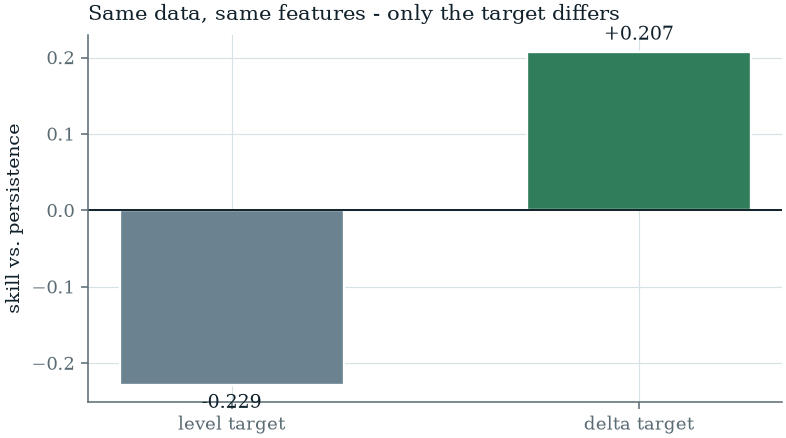

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
values = [mv.skill(rmse_level, rmse_pers), mv.skill(rmse_delta, rmse_pers)]
bars = ax.bar(["level target", "delta target"], values,
              color=[mv.MUTED, mv.MODEL], width=0.55,
              edgecolor="white", linewidth=1.2)
ax.axhline(0, color=mv.INK, linewidth=1.0)
for b, v in zip(bars, values):
    ax.annotate(f"{v:+.3f}", (b.get_x() + b.get_width() / 2, v), ha="center",
                va="bottom" if v > 0 else "top",
                xytext=(0, 4 if v > 0 else -4), textcoords="offset points",
                fontsize=10, color=mv.INK)
ax.set(ylabel="skill vs. persistence",
       title="Same data, same features - only the target differs")
mv.save(fig, "02_delta_vs_level")
plt.show()

**Below zero means worse than doing nothing.** Identical features,
identical data, identical hyperparameters — the only change is what the model is
asked to predict.

(This is one site at one horizon, so treat the exact numbers as an illustration
of the mechanism rather than as the study's result; the pooled, cross-validated
version across all 24 sites is in notebook 04.)

For circular variables (wave direction) the delta is the *signed angular change*
wrapped to (-180 deg, 180 deg], and decoding is modulo 360 deg. A raw
subtraction would make a 2 deg veer across north look like a 358 deg
reversal.

## Leakage discipline

Two properties have to hold, and both are checked here rather than asserted:

1. **Exactly one forward shift exists** — the target construction. Everything
   else is trailing by construction.
2. **Horizon 0 is rejected**, not merely discouraged — which is what makes
   windows closing at *t* inclusive safe.

In [10]:
import inspect
from forecasting import feature_engineering as fe

source = inspect.getsource(fe)
forward = [l.strip() for l in source.splitlines()
           if ".shift(-" in l and not l.strip().startswith("#")]
print(f"forward shifts in feature_engineering.py: {len(forward)}")
for line in forward:
    print("   ", line)

print()
print("horizon=0:")
try:
    build_features(wide, variable, config.features_for(VARIABLE),
                   latitude=latitude, longitude=longitude, horizon=0)
    print("    NOT REJECTED - this would be a leak")
except Exception as exc:
    print(f"    rejected -> {type(exc).__name__}: {exc}")

forward shifts in feature_engineering.py: 1
    frame[TARGET] = frame[column].shift(-horizon)

horizon=0:
    rejected -> FeatureError: forecast horizon must be >= 1 step, got 0. A zero horizon is a nowcast, not a forecast, and would make the trailing features leak the target.


## Rolling-origin cross-validation

Random k-fold on a time series trains on the future to predict the past. The
validation here is **rolling-origin with an embargo gap equal to the forecast
horizon** — a training row within *h* days of the test window shares its target
period, so it must be dropped.

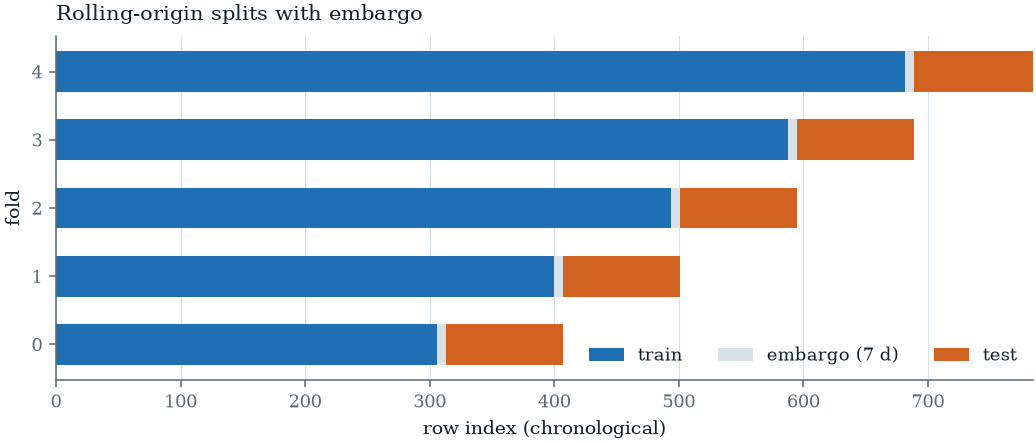

5 folds; every test window starts at least 7 rows after its training window ends


In [11]:
from forecasting.evaluator import rolling_origin_splits

splits = list(rolling_origin_splits(
    frame["timestamp"], n_splits=5, horizon_steps=HORIZON,
    embargo_steps=HORIZON, min_train_fraction=0.4))

fig, ax = plt.subplots(figsize=(9, 3.2))
for i, s in enumerate(splits):
    ax.barh(i, len(s.train), left=s.train[0], height=0.6,
            color=mv.PERSISTENCE, label="train" if i == 0 else None)
    gap = s.test[0] - (s.train[-1] + 1)
    if gap > 0:
        ax.barh(i, gap, left=s.train[-1] + 1, height=0.6, color=mv.RULE,
                label=f"embargo ({HORIZON} d)" if i == 0 else None)
    ax.barh(i, len(s.test), left=s.test[0], height=0.6,
            color=mv.CLIMATOLOGY, label="test" if i == 0 else None)
ax.set(xlabel="row index (chronological)", ylabel="fold",
       yticks=range(len(splits)), xlim=(0, len(frame)),
       title="Rolling-origin splits with embargo")
ax.legend(ncol=3)
ax.grid(axis="y", visible=False)
mv.save(fig, "02_cv_splits")
plt.show()

print(f"{len(splits)} folds; every test window starts at least {HORIZON} rows "
      f"after its training window ends")

## Takeaways

1. **~59 features per row**, in six families, all trailing.
2. **The final *h* rows have no target and must be dropped** — the trainer does
   it, and anything reproducing the trainer has to do it too.
3. **Cyclical encoding** restores day-of-year adjacency across the year boundary.
4. **The delta target is load-bearing, not a refinement.** On identical data and
   features, the level formulation loses to persistence and the delta formulation
   beats it — because a tree can represent the constant zero function but not the
   identity.
5. **Exactly one forward shift exists**, and horizon 0 is rejected outright.
6. **Rolling-origin CV with a horizon-length embargo**, never random k-fold.

Next: **03 — baselines and the model**, where the climatology this study adds is
defined and fitted.